In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
# List of London borough names
london_boroughs = [
    "Barking and Dagenham", "Barnet", "Bexley", "Brent", "Bromley",
    "Camden", "City of London", "Croydon", "Ealing", "Enfield", "Greenwich",
    "Hackney", "Hammersmith and Fulham", "Haringey", "Harrow", "Havering",
    "Hillingdon", "Hounslow", "Islington", "Kensington and Chelsea", "Kingston upon Thames",
    "Lambeth", "Lewisham", "Merton", "Newham", "Redbridge",
    "Richmond upon Thames", "Southwark", "Sutton", "Tower Hamlets", "Waltham Forest",
    "Wandsworth", "Westminster"
    ]

In [3]:
# Directory where shapefiles are stored
shapefile_dir = "../Shapefile/LB_shp_2021/"

# List to store successfully loaded shapefiles
valid_gdfs = []

for borough in london_boroughs:
    shp_file = f"{shapefile_dir}{borough}.shp"  # Keep borough name unchanged
    
    try:
        # Attempt to read shapefile
        gdf = gpd.read_file(shp_file)
        valid_gdfs.append(gdf)
        print(f"Successfully loaded: {shp_file}")
    except Exception as e:
        # Handle errors (e.g., file not found)
        print(f"Error: Failed to load {shp_file} - {e}")

# Merge all successfully loaded shapefiles
if valid_gdfs:
    london_lsoa = gpd.GeoDataFrame(pd.concat(valid_gdfs, ignore_index=True))
    
    print("All boroughs merged successfully.")
else:
    print("No shapefiles loaded. Please check file paths and formats.")


Successfully loaded: ../Shapefile/LB_shp_2021/Barking and Dagenham.shp
Successfully loaded: ../Shapefile/LB_shp_2021/Barnet.shp
Successfully loaded: ../Shapefile/LB_shp_2021/Bexley.shp
Successfully loaded: ../Shapefile/LB_shp_2021/Brent.shp
Successfully loaded: ../Shapefile/LB_shp_2021/Bromley.shp
Successfully loaded: ../Shapefile/LB_shp_2021/Camden.shp
Successfully loaded: ../Shapefile/LB_shp_2021/City of London.shp
Successfully loaded: ../Shapefile/LB_shp_2021/Croydon.shp
Successfully loaded: ../Shapefile/LB_shp_2021/Ealing.shp
Successfully loaded: ../Shapefile/LB_shp_2021/Enfield.shp
Successfully loaded: ../Shapefile/LB_shp_2021/Greenwich.shp
Successfully loaded: ../Shapefile/LB_shp_2021/Hackney.shp
Successfully loaded: ../Shapefile/LB_shp_2021/Hammersmith and Fulham.shp
Successfully loaded: ../Shapefile/LB_shp_2021/Haringey.shp
Successfully loaded: ../Shapefile/LB_shp_2021/Harrow.shp
Successfully loaded: ../Shapefile/LB_shp_2021/Havering.shp
Successfully loaded: ../Shapefile/LB_shp

In [4]:
london_lsoa.columns

Index(['lsoa21cd', 'lsoa21nm', 'msoa21cd', 'msoa21nm', 'lad22cd', 'lad22nm',
       'geometry'],
      dtype='object')

In [5]:
london_lsoa.rename(columns={'lsoa21cd': 'LSOA21CD'}, inplace=True)
london_lsoa.drop(columns=['msoa21cd', 'msoa21nm'], inplace=True)

In [6]:
# Print the number of LSOAs in London for 2021
print("Number of LSOAs in London (2011):", len(london_lsoa))

Number of LSOAs in London (2011): 4994


In [7]:
london_lsoa.crs

<Projected CRS: EPSG:27700>
Name: OSGB36 / British National Grid
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: United Kingdom (UK) - offshore to boundary of UKCS within 49°45'N to 61°N and 9°W to 2°E; onshore Great Britain (England, Wales and Scotland). Isle of Man onshore.
- bounds: (-9.01, 49.75, 2.01, 61.01)
Coordinate Operation:
- name: British National Grid
- method: Transverse Mercator
Datum: Ordnance Survey of Great Britain 1936
- Ellipsoid: Airy 1830
- Prime Meridian: Greenwich

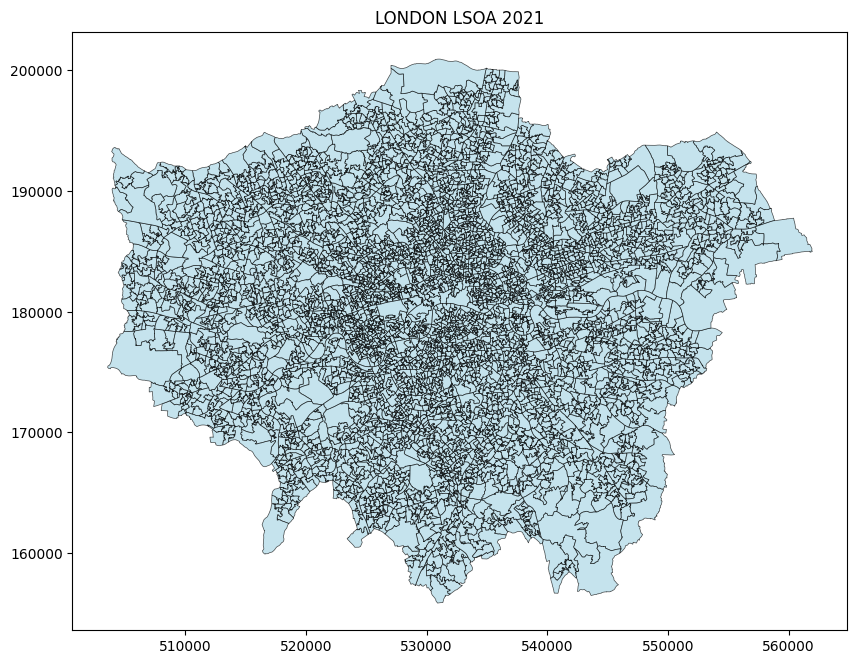

In [8]:
fig, ax = plt.subplots(figsize=(10, 10))
london_lsoa.plot(ax=ax, edgecolor="black", linewidth=0.5, alpha=0.7, color="lightblue")
plt.title('LONDON LSOA 2021')
plt.show()

In [9]:
london_lsoa.to_file("../Output/London_LSOA_2021.shp")

In [10]:
EW_2011 = gpd.read_file("../Shapefile/Lower_layer_Super_Output_Areas_Dec_2011_EW/LSOA_2011_EW_BFC_V3.shp")
EW_2001 = gpd.read_file("../Shapefile/Lower_Layer_Super_Output_Areas_Dec_2001_EW/LSOA_2001_EW_BFC_V2.shp")

In [11]:
EW_2001

,LSOA01CD,LSOA01NM,LSOA01NMW,GlobalID,geometry
0,E01000001,City of London 001A,City of London 001A,cc30fabd-068b-4308-8f6b-f7c3b5a70bd9,"POLYGON ((532151.55 181867.396, 532152.5 18186..."
1,E01000002,City of London 001B,City of London 001B,14c8ee1b-d6f0-4afe-a05c-14a69530e38e,"POLYGON ((532634.494 181926.001, 532632.048 18..."
2,E01000003,City of London 001C,City of London 001C,c6b8af00-b5da-4582-8019-3ccc9c294e50,"POLYGON ((532153.702 182165.155, 532158.25 182..."
3,E01000004,City of London 001D,City of London 001D,7f890d5b-77d9-49b7-b355-605c03f3e2e5,"POLYGON ((533383.486 181914.371, 533372.156 18..."
4,E01000005,City of London 001E,City of London 001E,c0158609-c7de-4fed-92bd-611ed8284dce,"POLYGON ((533619.062 181402.364, 533639.868 18..."
...,...,...,...,...,...
34373,W01001892,Cardiff 020D,Caerdydd 020D,065aabb5-49f7-4bd6-afef-d77fa1d646d2,"POLYGON ((316312.6 179604.873, 316313.708 1796..."
34374,W01001893,Cardiff 010B,Caerdydd 010B,6ef7c18f-14ef-4893-b644-cb33b90c2340,"POLYGON ((314465.5 184490.094, 314475.156 1844..."
34375,W01001894,Cardiff 010C,Caerdydd 010C,f8427f43-c56d-4a52-9e0e-69e026b9771e,"POLYGON ((314701.67 181340.979, 314703.688 181..."
34376,W01001895,Cardiff 010D,Caerdydd 010D,708ba932-2b8f-49f7-bc87-5812ac171b91,"POLYGON ((313722.925 181463.766, 313744.055 18..."


In [12]:
EW_2001.columns

Index(['LSOA01CD', 'LSOA01NM', 'LSOA01NMW', 'GlobalID', 'geometry'], dtype='object')

In [13]:
EW_2001.drop(columns=['LSOA01NMW', 'GlobalID'], inplace=True)

In [14]:
EW_2011

,LSOA11CD,LSOA11NM,BNG_E,BNG_N,LONG_,LAT,Shape_Leng,GlobalID,geometry
0,E01000001,City of London 001A,532123,181632,-0.097140,51.5182,2635.767993,eaf9e4b8-fcc1-4cae-a46c-22c8a43ff39b,"POLYGON ((532151.537 181867.433, 532152.5 1818..."
1,E01000002,City of London 001B,532480,181715,-0.091970,51.5188,2707.881853,4434ca6e-e270-4e88-b3eb-4cfb37f62490,"POLYGON ((532634.497 181926.016, 532632.048 18..."
2,E01000003,City of London 001C,532239,182033,-0.095320,51.5217,1224.638192,d0ff9760-86dc-40da-ad33-3b1dc987ef04,"POLYGON ((532153.703 182165.155, 532158.25 182..."
3,E01000005,City of London 001E,533581,181283,-0.076270,51.5147,2275.805348,474caa9f-a6e3-4de2-8bc1-2f5b0da40271,"POLYGON ((533619.062 181402.364, 533639.868 18..."
4,E01000006,Barking and Dagenham 016A,544994,184274,0.089317,51.5387,1966.092607,ff2bc9a6-9e26-4415-9cec-eaea2c0a4f54,"POLYGON ((545126.852 184310.838, 545145.213 18..."
...,...,...,...,...,...,...,...,...,...
34748,W01001954,Cardiff 006F,312959,180574,-3.255820,51.5173,5567.813286,f20ba69b-ee42-4374-82dd-243222a192e7,"POLYGON ((312747.367 181262.1, 312751.477 1812..."
34749,W01001955,Swansea 025F,265633,193182,-3.942370,51.6214,6037.602710,d0688d9e-e27a-44e5-897a-3e485ea52b8e,"POLYGON ((265804.688 194161.261, 265815 194143..."
34750,W01001956,Swansea 023E,260586,192621,-4.015000,51.6151,13127.898240,c9673c37-fc1d-4d65-a157-f4d59a68a509,"POLYGON ((259961 194979.5, 259969.094 194978.5..."
34751,W01001957,Swansea 025G,265337,192555,-3.946400,51.6157,2829.597133,0cb5c3e9-2154-4f4f-9006-ec7b69c4516c,"POLYGON ((265154 192746, 265156 192738, 265158..."


In [15]:
EW_2011.columns

Index(['LSOA11CD', 'LSOA11NM', 'BNG_E', 'BNG_N', 'LONG_', 'LAT', 'Shape_Leng',
       'GlobalID', 'geometry'],
      dtype='object')

In [16]:
EW_2011.drop(columns=['BNG_E', 'BNG_N', 'LONG_', 'LAT', 'Shape_Leng', 'GlobalID'], inplace=True)

In [17]:
# Extract the borough name from the LSOA01NM column
# The format is usually like "Camden 001A", so we extract the part before the first number
EW_2011["borough_name"] = EW_2011["LSOA11NM"].str.extract(r"^([A-Za-z \-&']+?)\s+\d")

# Remove any leading or trailing whitespace
EW_2011["borough_name"] = EW_2011["borough_name"].str.strip()

# Filter rows where the extracted borough name is in the official list
filtered_EW_2011 = EW_2011[EW_2011["borough_name"].isin(london_boroughs)]

# Print the number of LSOAs in London for 2011
print("Number of LSOAs in London (2011):", len(filtered_EW_2011))

Number of LSOAs in London (2011): 4835


In [18]:
filtered_EW_2011.crs

<Projected CRS: EPSG:27700>
Name: OSGB36 / British National Grid
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: United Kingdom (UK) - offshore to boundary of UKCS within 49°45'N to 61°N and 9°W to 2°E; onshore Great Britain (England, Wales and Scotland). Isle of Man onshore.
- bounds: (-9.01, 49.75, 2.01, 61.01)
Coordinate Operation:
- name: British National Grid
- method: Transverse Mercator
Datum: Ordnance Survey of Great Britain 1936
- Ellipsoid: Airy 1830
- Prime Meridian: Greenwich

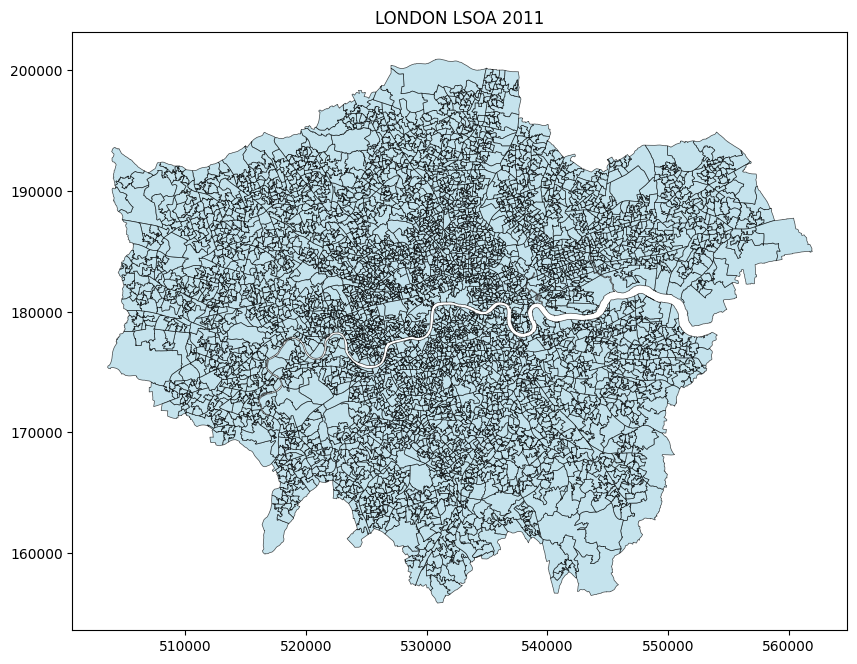

In [19]:
fig, ax = plt.subplots(figsize=(10, 10))
filtered_EW_2011.plot(ax=ax, edgecolor="black", linewidth=0.5, alpha=0.7, color="lightblue")
plt.title('LONDON LSOA 2011')
plt.show()

In [20]:
filtered_EW_2011.to_file("../Output/London_LSOA_2011.shp")

C:\Users\wbwha\AppData\Local\Temp\ipykernel_4552\2088129741.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  filtered_EW_2011.to_file("../Output/London_LSOA_2011.shp")
c:\Users\wbwha\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'borough_name' to 'borough_na'
  ogr_write(


In [21]:
# Extract the borough name from the LSOA01NM column
# The format is usually like "Camden 001A", so we extract the part before the first number
EW_2001["borough_name"] = EW_2001["LSOA01NM"].str.extract(r"^([A-Za-z \-&']+?)\s+\d")

# Remove any leading or trailing whitespace
EW_2001["borough_name"] = EW_2001["borough_name"].str.strip()

# Filter rows where the extracted borough name is in the official list
filtered_EW_2001 = EW_2001[EW_2001["borough_name"].isin(london_boroughs)]

# Print the number of LSOAs in London for 2001
print("Number of LSOAs in London (2001):", len(filtered_EW_2001))

Number of LSOAs in London (2001): 4765


In [22]:
filtered_EW_2001.crs

<Projected CRS: EPSG:27700>
Name: OSGB36 / British National Grid
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: United Kingdom (UK) - offshore to boundary of UKCS within 49°45'N to 61°N and 9°W to 2°E; onshore Great Britain (England, Wales and Scotland). Isle of Man onshore.
- bounds: (-9.01, 49.75, 2.01, 61.01)
Coordinate Operation:
- name: British National Grid
- method: Transverse Mercator
Datum: Ordnance Survey of Great Britain 1936
- Ellipsoid: Airy 1830
- Prime Meridian: Greenwich

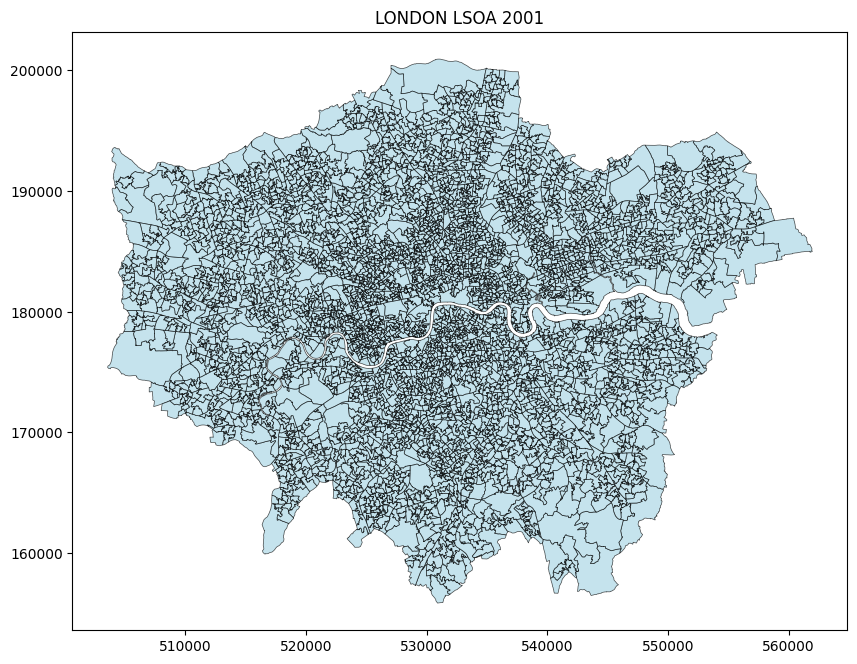

In [23]:
fig, ax = plt.subplots(figsize=(10, 10))
filtered_EW_2001.plot(ax=ax, edgecolor="black", linewidth=0.5, alpha=0.7, color="lightblue")
plt.title('LONDON LSOA 2001')
plt.show()

In [24]:
filtered_EW_2001.to_file("../Output/London_LSOA_2001.shp")

C:\Users\wbwha\AppData\Local\Temp\ipykernel_4552\615619271.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  filtered_EW_2001.to_file("../Output/London_LSOA_2001.shp")
c:\Users\wbwha\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'borough_name' to 'borough_na'
  ogr_write(
